In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes

100%|██████████| 170M/170M [00:04<00:00, 34.8MB/s]


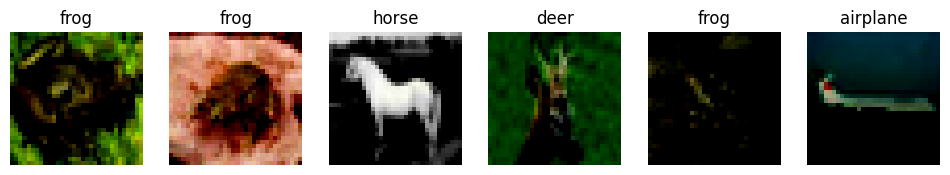

In [3]:
images, labels = next(iter(trainloader))

fig, axes = plt.subplots(1,6, figsize=(12,3))
for i in range(6):
    axes[i].imshow(np.transpose(images[i], (1,2,0)))
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')
plt.show()

In [4]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN,self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [5]:
def train_model(model, epochs=10):

    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses=[]
    val_losses=[]

    start=time.time()

    for epoch in range(epochs):

        model.train()
        running_loss=0

        for images,labels in trainloader:

            images,labels = images.to(device),labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            running_loss+=loss.item()

        train_losses.append(running_loss/len(trainloader))

        print(f"Epoch {epoch+1}, Loss {train_losses[-1]:.4f}")

    total_time=time.time()-start
    return train_losses,total_time

In [6]:
simple_model = SimpleCNN()

losses_simple, time_simple = train_model(simple_model,10)

Epoch 1, Loss 1.3522
Epoch 2, Loss 0.9735
Epoch 3, Loss 0.8393
Epoch 4, Loss 0.7553
Epoch 5, Loss 0.6886
Epoch 6, Loss 0.6286
Epoch 7, Loss 0.5885
Epoch 8, Loss 0.5459
Epoch 9, Loss 0.5105
Epoch 10, Loss 0.4784


In [7]:
def evaluate_model(model):

    model.eval()

    correct=0
    total=0
    all_preds=[]
    all_labels=[]

    with torch.no_grad():

        for images,labels in testloader:

            images,labels=images.to(device),labels.to(device)

            outputs=model(images)

            _,predicted=torch.max(outputs,1)

            correct+=(predicted==labels).sum().item()
            total+=labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc=100*correct/total
    print("Accuracy:",acc)

    cm = confusion_matrix(all_labels,all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm,annot=True)
    plt.title("Confusion Matrix")
    plt.show()

    return acc

Accuracy: 76.78


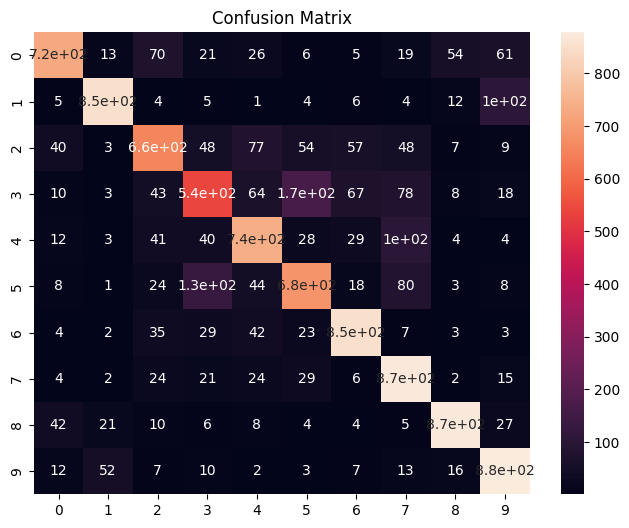

In [8]:
acc_simple = evaluate_model(simple_model)

In [9]:
transfer_model = models.resnet18(pretrained=True)

for param in transfer_model.parameters():
    param.requires_grad = False

transfer_model.fc = nn.Linear(512,10)

transfer_model = transfer_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


Epoch 1, Loss 1.7346
Epoch 2, Loss 1.5995
Epoch 3, Loss 1.5804
Epoch 4, Loss 1.5720
Epoch 5, Loss 1.5671
Accuracy: 45.59


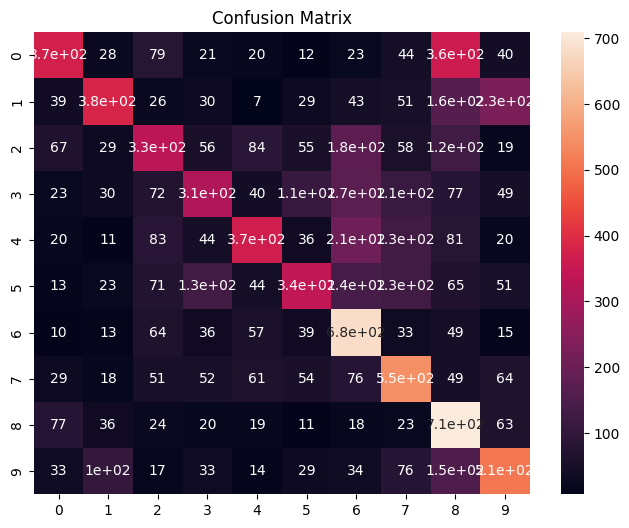

In [10]:
losses_transfer, time_transfer = train_model(transfer_model,5)
acc_transfer = evaluate_model(transfer_model)

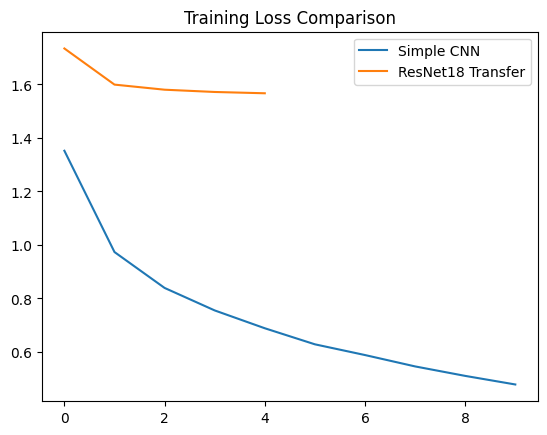

In [11]:
plt.plot(losses_simple,label="Simple CNN")
plt.plot(losses_transfer,label="ResNet18 Transfer")
plt.legend()
plt.title("Training Loss Comparison")
plt.show()

In [12]:
def model_size(model):
    return sum(p.numel() for p in model.parameters())

print("Simple CNN params:",model_size(simple_model))
print("ResNet params:",model_size(transfer_model))

print("Training time simple:",time_simple)
print("Training time transfer:",time_transfer)

Simple CNN params: 620554
ResNet params: 11181642
Training time simple: 154.42838716506958
Training time transfer: 93.73511099815369


In [1]:
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    return acc

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes

class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN,self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def train_model(model, epochs=10):

    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses=[]
    val_losses=[]

    start=time.time()

    for epoch in range(epochs):

        model.train()
        running_loss=0

        for images,labels in trainloader:

            images,labels = images.to(device),labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            running_loss+=loss.item()

        train_losses.append(running_loss/len(trainloader))

        print(f"Epoch {epoch+1}, Loss {train_losses[-1]:.4f}")

    total_time=time.time()-start
    return train_losses,total_time

def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    return acc

simple_model = SimpleCNN()
losses_simple, time_simple = train_model(simple_model,10)

transfer_model = models.resnet18(pretrained=True)
for param in transfer_model.parameters():
    param.requires_grad = False
transfer_model.fc = nn.Linear(512,10)
transfer_model = transfer_model.to(device)
losses_transfer, time_transfer = train_model(transfer_model,5)

acc_simple = evaluate(simple_model)
acc_transfer = evaluate(transfer_model)

print("Simple CNN Accuracy:", acc_simple)
print("Transfer Learning Accuracy:", acc_transfer)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


Epoch 1, Loss 1.3958
Epoch 2, Loss 1.0126
Epoch 3, Loss 0.8773
Epoch 4, Loss 0.7902
Epoch 5, Loss 0.7279
Epoch 6, Loss 0.6714
Epoch 7, Loss 0.6378
Epoch 8, Loss 0.5839
Epoch 9, Loss 0.5553


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 10, Loss 0.5218
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


Epoch 1, Loss 1.7317
Epoch 2, Loss 1.5991
Epoch 3, Loss 1.5770
Epoch 4, Loss 1.5690
Epoch 5, Loss 1.5761
Simple CNN Accuracy: 75.7
Transfer Learning Accuracy: 45.36


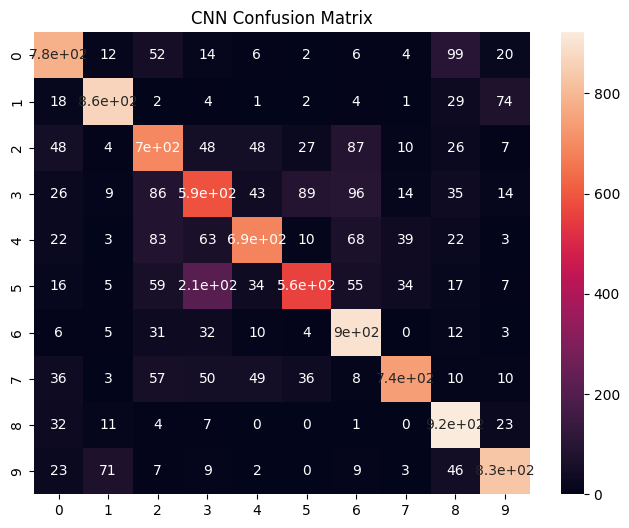

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

simple_model.eval()

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)

        outputs = simple_model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True)
plt.title("CNN Confusion Matrix")
plt.show()

In [10]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [11]:
import torchvision.models as models

transfer_model = models.resnet18(weights="DEFAULT")

transfer_model.fc = nn.Linear(512,10)

transfer_model = transfer_model.to(device)

In [12]:
losses_transfer, time_transfer = train_model(transfer_model,15)

Epoch 1, Loss 0.9659
Epoch 2, Loss 0.6570
Epoch 3, Loss 0.5135
Epoch 4, Loss 0.4572
Epoch 5, Loss 0.3489
Epoch 6, Loss 0.2953
Epoch 7, Loss 0.2123
Epoch 8, Loss 0.1792
Epoch 9, Loss 0.1546
Epoch 10, Loss 0.1444
Epoch 11, Loss 0.0968
Epoch 12, Loss 0.0993
Epoch 13, Loss 0.1162
Epoch 14, Loss 0.0749
Epoch 15, Loss 0.0886


In [13]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224,padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [14]:
def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [15]:
acc_simple = evaluate_model(simple_model)
acc_transfer = evaluate_model(transfer_model)

print("Simple CNN Accuracy:", acc_simple)
print("Transfer Learning Accuracy:", acc_transfer)

Simple CNN Accuracy: 75.7
Transfer Learning Accuracy: 81.2


In [16]:
images, labels = next(iter(testloader))

images = images.to(device)

outputs = simple_model(images)

_, preds = torch.max(outputs,1)

print("Predicted:", preds[:10].cpu().numpy())
print("Actual:", labels[:10].numpy())

Predicted: [3 8 8 8 6 6 1 2 3 1]
Actual: [3 8 8 0 6 6 1 6 3 1]


In [17]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128, shuffle=False)

In [18]:
class BetterCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(256*4*4,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,10)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x

In [19]:
model = BetterCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [20]:
epochs = 20

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    print("Epoch:",epoch+1,"Loss:",running_loss/len(trainloader))

Epoch: 1 Loss: 1.7289123644914164
Epoch: 2 Loss: 1.2977979750279576
Epoch: 3 Loss: 1.0931811143675119
Epoch: 4 Loss: 0.9653826340689988
Epoch: 5 Loss: 0.8829180819299215
Epoch: 6 Loss: 0.7529356282232972
Epoch: 7 Loss: 0.7112864249807489
Epoch: 8 Loss: 0.671413356843202
Epoch: 9 Loss: 0.6439272412253768
Epoch: 10 Loss: 0.6167192751032007
Epoch: 11 Loss: 0.5475518618093427
Epoch: 12 Loss: 0.5257261846681385
Epoch: 13 Loss: 0.5092623943410566
Epoch: 14 Loss: 0.4920495120460725
Epoch: 15 Loss: 0.48398960410329084
Epoch: 16 Loss: 0.44890003489411395
Epoch: 17 Loss: 0.43280627492748563
Epoch: 18 Loss: 0.4276453413240745
Epoch: 19 Loss: 0.4212155829915
Epoch: 20 Loss: 0.41883209378213226


In [21]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images,labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _,predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100*correct/total

print("Final Accuracy:",accuracy)

Final Accuracy: 86.18
